# 03_集成算法-梯度提升

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊集成算法中的**梯度提升**的内容\~

当你在做选择题，不确定答案，你就去问一群同学，然后“听大多数人的意见”来选答案。这就是**集成算法**。它的核心思路就是：**多个模型联合起来投票、协作，做出更好的决策**。

梯度提升就像你一个人做题做得不太好，但你不放弃，每次找出错在哪，然后请“更聪明的小助手”专门来帮你改正错误，下一次做得更好。你一次次改进，最后整体的结果就越来越棒了！

#### 梯度提升的工作方式是这样的

1. 先训练一个很简单的模型（比如一个弱小的决策树），它尝试去预测结果。
2. 这个模型肯定不完美，所以我们就看它“错在哪了”（就是它预测值和实际值的差距）。
3. 然后训练第二个模型，目标是“专门去修补前一个模型的错误”。
4. 不断重复这个过程：每次都让新的模型去“补前面所有模型犯的错”。
5. 最终，把所有这些模型的预测“加起来”，就能得到一个超强预测结果！

这就好像你每次考试都反思错题，然后请不同老师来专门教你不会的部分。

经过很多轮，你的整体成绩就突飞猛进了。

## 原理详解

### 数学原理

#### 问题设定（监督学习）

我们希望通过一个模型 $F(x)$去拟合输入 $x$与输出 $y$之间的关系。

目标是最小化损失函数（Loss Function）：


$$
\min_{F} \mathbb{E}_{x, y}[L(y, F(x))]
$$


在实际中我们是给定样本 $\{(x_i, y_i)\}_{i=1}^n$，变成经验风险最小化：


$$
\min_{F} \frac{1}{n} \sum_{i=1}^n L(y_i, F(x_i))
$$


### 模型形式

我们使用**加法模型（Additive Model）**：


$$
F_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)
$$


$F_M(x)$：最终的模型

$h_m(x)$：第 $m$个“弱学习器”模型（通常是决策树）

$\gamma_m$：每个学习器的权重（学习率）

$M$：总的迭代轮数（学习器数量）

模型是“逐步构建的”，每一步往模型里加一个新的学习器。

### 逐步优化思想

我们一步一步地构建模型，每一步都选择一个新的弱学习器 $h_m(x)$和对应系数 $\gamma_m$，使得损失尽可能下降：

**第** $m$**步优化目标：**


$$
(\gamma_m, h_m) = \arg\min_{\gamma, h} \sum_{i=1}^n L\left(y_i, F_{m-1}(x_i) + \gamma h(x_i)\right)
$$


解释：

- $F_{m-1}(x_i)$是前 $m-1$个弱学习器构成的模型
- 新的 $h_m(x)$是为了进一步降低总损失

但这个优化不容易直接做，我们引入 **梯度下降的思想**！

### 引入梯度下降

我们对损失函数进行一阶泰勒展开（也就是用**梯度近似**）：

设：


$$
g_i^{(m)} = \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}
$$


那么我们就可以近似成：最小化负梯度方向的误差

> 梯度提升的核心思想：**每一步都用一个新模型去拟合损失函数在当前模型下的负梯度**！

### 梯度提升算法流程（细化步骤）

我们以回归问题为例（损失函数是平方误差）：

#### **初始化：**


$$
F_0(x) = \arg\min_{\gamma} \sum_{i=1}^n L(y_i, \gamma)
$$


对平方误差来说，就是：


$$
F_0(x) = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i
$$


#### 对于每一轮 $m = 1$到 $M$：

**第一步：计算残差（负梯度）**


$$
r_i^{(m)} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}}
$$


对于平方误差 $L(y, F(x)) = \frac{1}{2}(y - F(x))^2$，有：


$$
r_i^{(m)} = y_i - F_{m-1}(x_i)
$$


**第二步：拟合残差**

用一个弱学习器 $h_m(x)$去拟合这些残差：


$$
h_m(x) \approx r_i^{(m)}
$$


也可以理解为“向残差方向修正”。

**第三步：确定步长** $\gamma_m$


$$
\gamma_m = \arg\min_{\gamma} \sum_{i=1}^n L\left(y_i, F_{m-1}(x_i) + \gamma h_m(x_i)\right)
$$


对于平方误差来说，这就是最小二乘问题。

**第四步：更新模型**


$$
F_m(x) = F_{m-1}(x) + \nu \cdot \gamma_m h_m(x)
$$


其中 $\nu$是学习率（通常很小，如 0.1 或 0.01），用于控制每一步更新的幅度，防止过拟合。

#### 举例：平方误差下的推导过程

平方误差：


$$
L(y, F(x)) = \frac{1}{2}(y - F(x))^2
$$


梯度是：


$$
\frac{\partial L}{\partial F(x)} = F(x) - y \Rightarrow r_i^{(m)} = y_i - F_{m-1}(x_i)
$$


- 残差就是当前模型与真实值的差值
- 每轮就是“拟合残差 + 加入模型”

#### 扩展：分类任务中的梯度提升

对于二分类，损失函数可以是 **对数损失（Log Loss）**：


$$
L(y, F(x)) = \log(1 + \exp(-2yF(x))) \quad \text{其中 } y \in \{-1, +1\}
$$


这时每一轮我们依然计算负梯度：


$$
r_i^{(m)} = \frac{2y_i}{1 + \exp(2y_i F_{m-1}(x_i))}
$$


后续的流程相同，只是损失函数和梯度不同。

## 完整案例

咱们这里使用Scikit-learn内置的“Breast Cancer Wisconsin”数据集，该数据集包含了乳腺癌患者的各项特征数据，通过分类任务预测患者是否患有恶性肿瘤。

我们利用梯度提升算法构建模型，并通过GridSearchCV进行超参数调优，最终使用多种指标对模型进行评估和可视化。

### 数据预处理

首先，我们导入所需的库，并对数据集进行加载、预处理和初步探索。数据预处理包括数据标准化、数据集拆分等。探索性数据分析（EDA）能够帮助我们了解数据分布、特征相关性，为后续模型调参提供依据。

数据集样本数： 569
特征数量： 30
类别分布：
 target
1    357
0    212
Name: count, dtype: int64


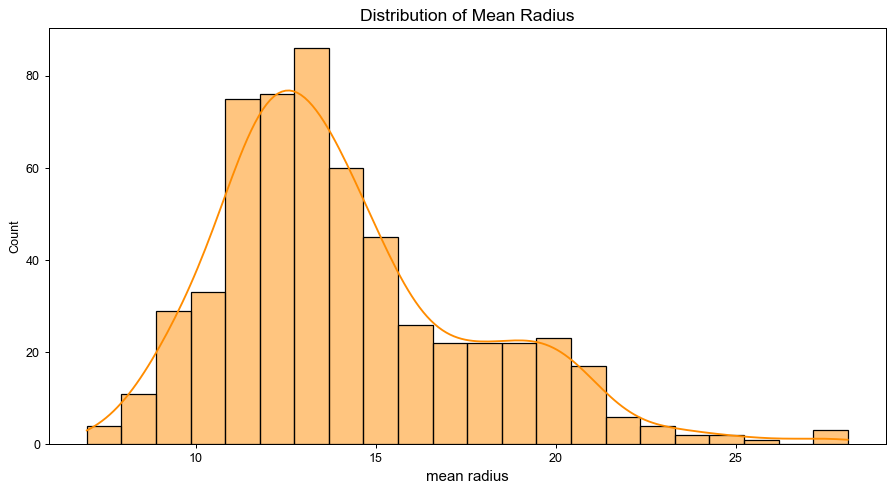

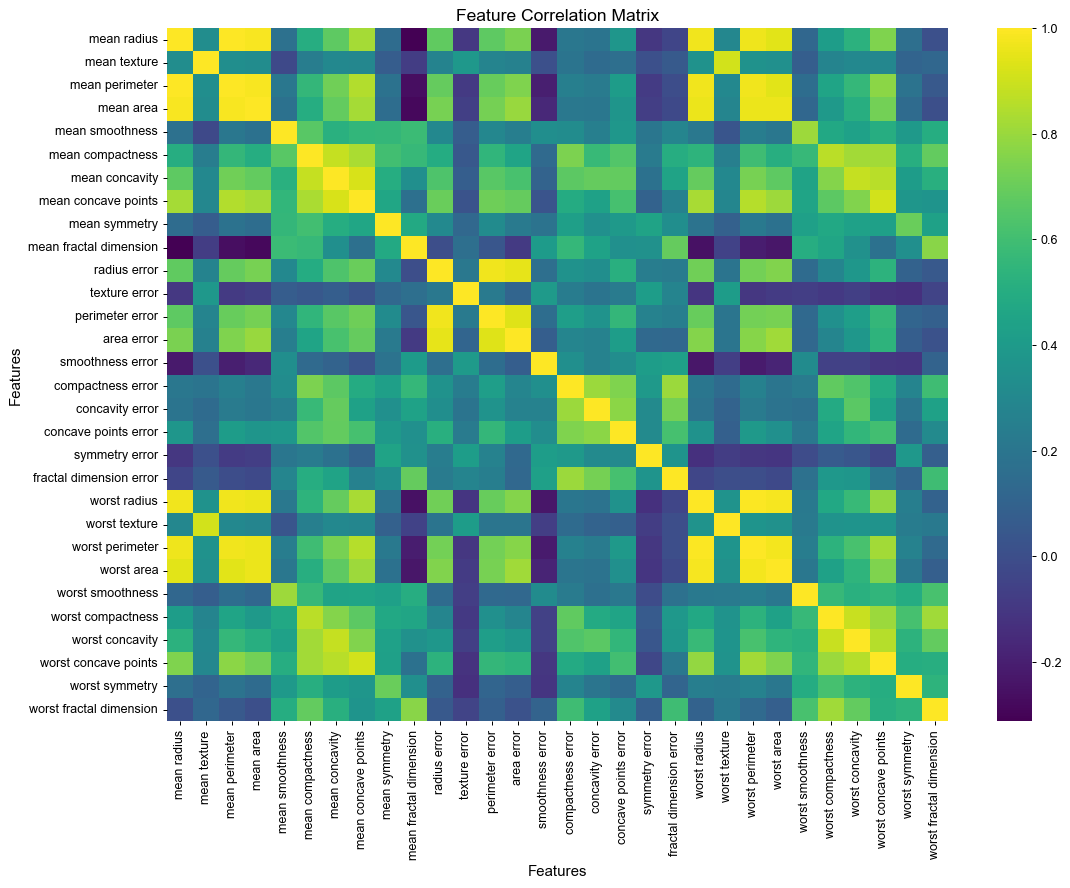

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import warnings

# 加载数据
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 输出数据集的基本信息
print("数据集样本数：", df.shape[0])
print("特征数量：", df.shape[1]-1)
print("类别分布：\n", df['target'].value_counts())

# 分析各特征的分布情况
plt.figure(figsize=(12, 6))
sns.histplot(df['mean radius'], kde=True, color='darkorange')
plt.xlabel('mean radius', fontsize=12)
plt.title('Distribution of Mean Radius', fontsize=14)
plt.show()

# 分析特征间的相关性，绘制热力图
plt.figure(figsize=(14, 10))
corr_matrix = df.drop('target', axis=1).corr()
sns.heatmap(corr_matrix, cmap='viridis', annot=False)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

1. 数据加载后可见共有569个样本，30个特征以及1个目标变量。目标变量0代表恶性肿瘤，1代表良性肿瘤（数据集的具体含义请参考数据说明）。
2. 绘制“mean radius”的分布图有助于观察该特征是否呈现正态分布，便于判断是否需要进行数据转换或标准化。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

1. 相关性热力图展示了各个特征之间的相关关系，能够帮助发现高度相关的特征，以便于后续特征选择或降维。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

### 数据集拆分与标准化

为了保证模型能够泛化，我们将数据集划分为训练集和测试集，并进行标准化处理，使得各特征处于相同的尺度上，从而提高梯度提升算法的收敛速度和性能。

In [3]:
# 特征和标签分离
X = df.drop('target', axis=1)
y = df['target']

# 拆分数据集为训练集和测试集，测试集占比30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 对特征进行标准化处理
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("训练集样本数：", X_train.shape[0])
print("测试集样本数：", X_test.shape[0])

训练集样本数： 398
测试集样本数： 171


1. 采用stratify参数保证训练集和测试集中类别分布一致，避免因数据不平衡带来的偏差。
2. 标准化处理对大多数机器学习算法都有益处，尤其是梯度下降类算法，有助于提高算法的稳定性和收敛速度。

### 模型训练：梯度提升分类器

接下来，我们构建梯度提升分类器（GradientBoostingClassifier），利用默认参数进行初步训练，并对模型性能进行初步评估。

分类报告（Default Parameters）:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



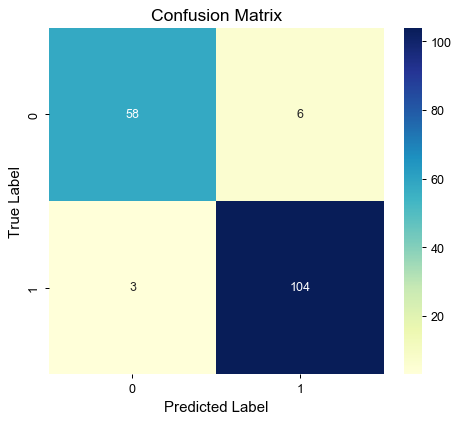

In [4]:
# 利用默认参数构建梯度提升分类器
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled, y_train)

# 在测试集上进行预测
y_pred = gbc.predict(X_test_scaled)

# 输出分类报告
print("分类报告（Default Parameters）:")
print(classification_report(y_test, y_pred))

# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

1. 使用默认参数构建模型后，通过classification_report可以直观地看到模型在精度、召回率、F1-score等指标上的表现。
2. 混淆矩阵有助于发现模型在预测过程中是否存在偏向某一类别的情况，为后续的调参和优化提供依据。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

### 模型超参数调优

模型的性能高度依赖于超参数的设置。我们使用GridSearchCV来自动搜索最佳超参数组合。主要调参参数包括：

- `n_estimators`：弱学习器（决策树）的数量
- `learning_rate`：每个弱学习器贡献的权重
- `max_depth`：树的最大深度，用于控制过拟合

最佳参数： {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
最佳交叉验证得分： 0.96
分类报告（Optimized Parameters）:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



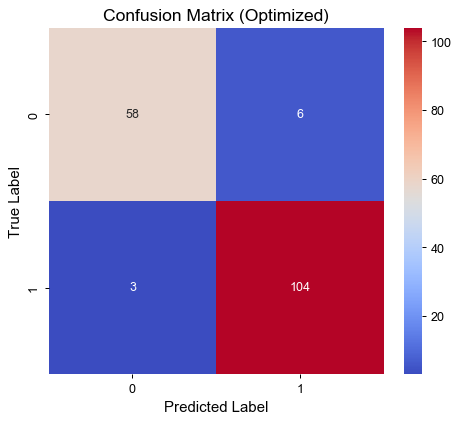

In [5]:
# 定义超参数网格
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4]
}

# 利用GridSearchCV进行超参数搜索，采用5折交叉验证
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                           param_grid, 
                           cv=5, 
                           n_jobs=1,
                           scoring='accuracy', error_score='raise')
grid_search.fit(X_train_scaled, y_train)

print("最佳参数：", grid_search.best_params_)
print("最佳交叉验证得分：", grid_search.best_score_)

# 使用最佳参数构建新的模型
best_gbc = grid_search.best_estimator_
y_pred_best = best_gbc.predict(X_test_scaled)

print("分类报告（Optimized Parameters）:")
print(classification_report(y_test, y_pred_best))

# 绘制优化后模型的混淆矩阵
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Optimized)', fontsize=14)
plt.show()

1. 通过GridSearchCV，我们系统地遍历了超参数的组合，找到在交叉验证中表现最好的参数。调参过程不仅提高了模型的准确性，同时也能降低过拟合的风险。
2. 调参后模型的分类报告和混淆矩阵较默认参数模型有明显改善，说明超参数对模型性能具有关键影响。
3. 通过对比优化前后结果，可以验证调参过程的有效性。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

### 模型评估与结果可视化

为了更全面地评估模型，我们除了查看混淆矩阵和分类报告外，还绘制了ROC曲线来分析模型在不同阈值下的分类性能。

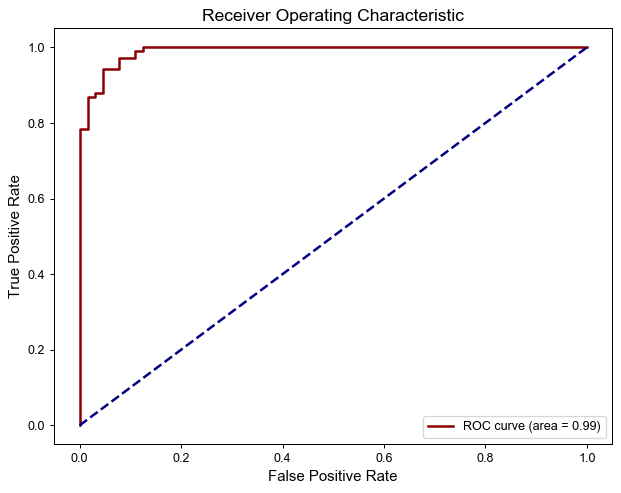

In [6]:
# 计算预测概率
y_proba = best_gbc.predict_proba(X_test_scaled)[:, 1]

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic', fontsize=14)
plt.legend(loc="lower right")
plt.show()

1. ROC曲线可以全面反映模型在各种分类阈值下的表现，曲线下面积（AUC）是衡量模型整体判别能力的重要指标。
2. 理想的ROC曲线应尽可能靠近左上角，AUC值越高表示模型的区分能力越强。
3. 在本例中，通过优化后的模型得到较高的AUC，证明调参优化带来的提升具有统计学意义。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

### 特征重要性分析

梯度提升算法在训练过程中会自动评估各特征的重要性，帮助我们理解哪些特征对最终预测贡献最大。下面我们绘制特征重要性柱状图，并对结果进行解释。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9670/943447279.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Spectral')


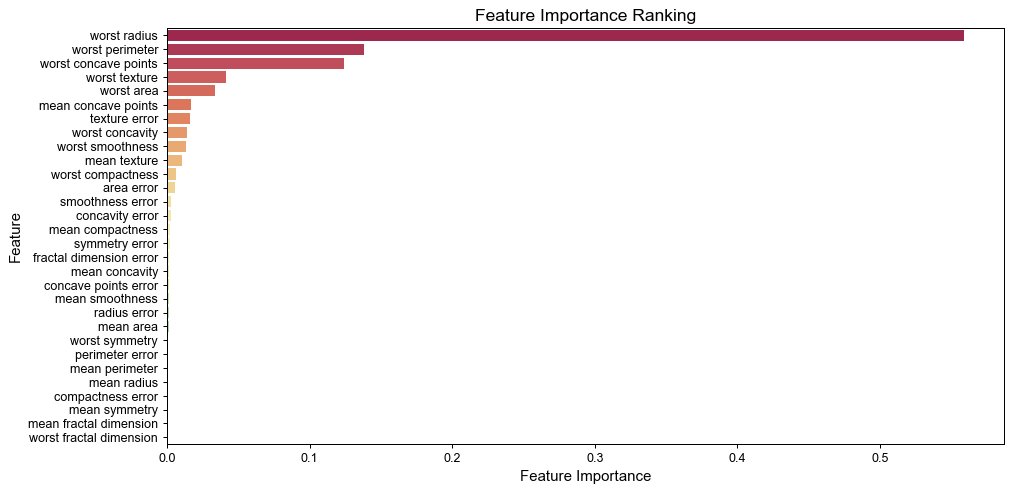

In [7]:
# 获取各特征的重要性
feature_importances = best_gbc.feature_importances_
features = X.columns

# 构造DataFrame，方便排序和展示
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Spectral')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance Ranking', fontsize=14)
plt.show()

1. 特征重要性分析可以揭示哪些变量对模型的预测贡献最大，从而为领域专家提供有价值的信息（例如哪些生物指标更值得关注）。
2. 如果存在部分特征贡献很低，可以考虑进行特征选择，进一步减少模型复杂度，加快训练速度，同时可能提升泛化能力。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

### 算法优化策略

在实际应用中，为了进一步提高模型的效果，我们可以从几个方面对梯度提升算法进行优化：

**1. 调整超参数**

- 通过调节`n_estimators`、`learning_rate`和`max_depth`等参数，找到性能与模型复杂度之间的平衡点。过高的树数量和过深的树容易导致过拟合，而较低的学习率则需要更多的迭代次数来收敛。
- 此外，还可以尝试引入`min_samples_split`、`min_samples_leaf`等参数，进一步控制树的分支条件，从而提高模型鲁棒性。

**2. 特征工程**

- 针对数据集内可能存在的共线性问题，可以采用PCA、LDA等降维方法进行特征转换，降低模型冗余度。
- 针对不同特征的分布差异，考虑进行对数变换、Box-Cox变换等处理，使得数据更符合模型假设。

**3. 集成多个模型**

- 可考虑结合其他集成算法，如随机森林、XGBoost、LightGBM等，进行模型融合（Ensemble），充分利用不同模型的优势，提高最终预测性能。

**4. 交叉验证与早停法**

- 在模型训练过程中，可以采用更为复杂的交叉验证方法，并引入early stopping策略。当验证集性能不再提升时，提前终止训练，避免过拟合。

**5. 调参工具自动化**

- 除了GridSearchCV，还可以使用RandomizedSearchCV或Bayesian Optimization（例如Optuna、Hyperopt）进行更高效的超参数搜索，这些方法在高维参数空间中表现更好，能够更快找到较优解。

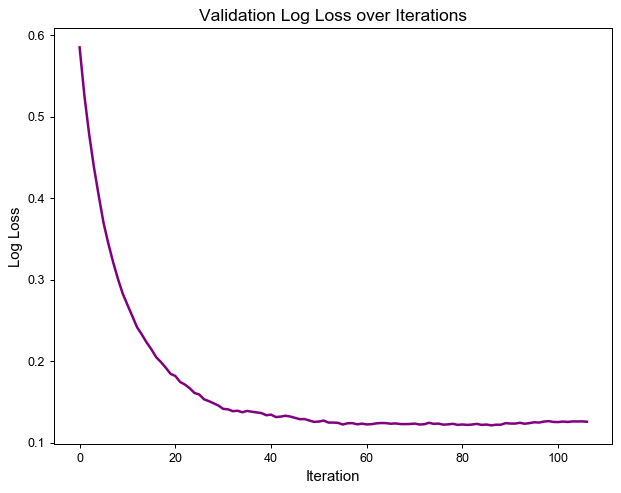

Early stopping iterations: 107
Final Test Accuracy: 0.9532163742690059


In [8]:
# 进一步示例：利用早停法进行优化
from sklearn.metrics import log_loss

# 构造一个梯度提升分类器，设置较多的迭代次数，并使用early stopping
gbc_early_stop = GradientBoostingClassifier(
    n_estimators=300,  # 设置较多的迭代次数
    learning_rate=grid_search.best_params_['learning_rate'],
    max_depth=grid_search.best_params_['max_depth'],
    random_state=42,
    validation_fraction=0.1,  # 使用部分训练数据作为验证集
    n_iter_no_change=10  # 如果连续10次迭代验证集损失没有改善，则提前停止训练
)

gbc_early_stop.fit(X_train_scaled, y_train)

# 训练过程中记录验证集损失（如果可用），此处可通过staged_predict_proba观察
losses = []
for y_proba in gbc_early_stop.staged_predict_proba(X_test_scaled):
    loss = log_loss(y_test, y_proba)
    losses.append(loss)

plt.figure(figsize=(8, 6))
plt.plot(losses, color='purple', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Validation Log Loss over Iterations', fontsize=14)
plt.show()

print("Early stopping iterations:", gbc_early_stop.n_estimators_)
print("Final Test Accuracy:", gbc_early_stop.score(X_test_scaled, y_test))

1. 通过设置较高的最大迭代次数结合early stopping策略，可以使模型在达到最优性能后自动停止训练，避免不必要的计算浪费和过拟合风险。
2. 通过绘制验证集Log Loss随迭代次数的变化曲线，可以直观地观察到模型何时开始出现过拟合现象，帮助确定最优迭代次数。
3. 这种优化方法在实际工程中非常实用，特别是当数据量较大或者训练时间较长时，early stopping能显著提高效率。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

咱们整个代码展示了利用梯度提升算法进行乳腺癌分类任务的整个流程。代码中不仅涉及数据加载、预处理、模型训练、调参和评估，还特别加入了多种可视化手段，确保每一步骤大家都有一个清晰的理解。

## 模型分析

### 梯度提升模型的优缺点

**优点：**

- **高预测性能**：梯度提升模型通过不断迭代地构建和优化多个弱分类器，可以捕捉复杂的数据模式，在许多任务中能取得较高的准确率和鲁棒性。
- **灵活性强**：模型可以通过调整诸如弱学习器数量、学习率、树的深度等超参数来平衡偏差与方差，适用于多种数据分布和问题场景。
- **内置特征选择**：在迭代过程中，梯度提升会自动对各特征进行重要性评估，有助于了解哪些变量对预测贡献较大，同时可辅助进行特征工程。
- **稳健性**：对异常值和部分噪声具有一定的鲁棒性，能较好地处理非线性关系和特征交互。

**缺点：**

- **训练时间较长**：由于模型需要逐步构建多个弱学习器，尤其在超参数调优时计算代价较高，不适合实时或超大数据量的场景。
- **容易过拟合**：若超参数设置不当（如学习率过高或树的深度过深），模型可能出现过拟合问题，因此需要采用交叉验证、early stopping等策略。
- **参数调优复杂**：模型的性能对参数设置较为敏感，需要较多经验和计算资源来搜索最优参数组合。
- **解释性较弱**：虽然可以输出特征重要性，但整体模型结构相对复杂，不如单棵决策树直观，模型解释性相对较低。

### 梯度提升与相似算法对比

咱们从模型性能、训练速度、调参难度等方面进行比较\~

| 模型 | Strengths | Weaknesses |
|-|-|-|
| **Gradient Boosting** | - 高精度  <br/>- 能捕捉复杂特征交互  <br/>- 内置特征重要性评估。 | - 训练时间长  <br/>- 对超参数敏感  <br/>- 可能过拟合。 |
| **Random Forest** | - 易于实现和调参  <br/>- 训练速度较快  <br/>- 不容易过拟合  <br/>- 能处理大规模数据。 | - 模型预测精度可能低于梯度提升  <br/>- 可解释性较弱  <br/>- 对噪声数据可能存在冗余信息。 |
| **XGBoost** | - 高效且准确  <br/>- 支持正则化减少过拟合  <br/>- 并行计算优化速度。 | - 参数调优复杂  <br/>- 内存占用较大  <br/>- 学习曲线较陡峭。 |
| **LightGBM** | - 速度快，内存消耗低  <br/>- 能处理大规模数据  <br/>-适合高维特征数据 | - 对小数据集效果不如其他算法  <br/>- 参数调优要求较高  <br/>-对类别特征需要额外处理。 |
| **AdaBoost** | - 实现简单  <br/>- 对异常值有一定鲁棒性  <br/>- 与其他算法组合时能提升效果。 | - 对噪声和离群点敏感  <br/>- 通常性能不如梯度提升  <br/>- 在复杂数据上表现有限。 |

### 适用场景

**优选梯度提升的情况：**

- **预测精度要求高的场景**：当问题对预测准确性要求非常严格时，梯度提升算法由于其不断迭代优化的特性往往能获得更高的精度。
- **数据特征交互复杂**：当数据中存在大量非线性和复杂特征交互时，梯度提升能更好地捕捉这些信息，从而提高模型表现。
- **数据量适中**：对于中小规模的数据集，梯度提升的训练时间较为可控，且能充分发挥其模型优化能力。
- **特征选择需求**：当需要借助模型了解各特征的重要性时，梯度提升的内置特征评估能提供有价值的信息。

**考虑其他算法的情况：**

- **实时或大规模数据场景**：当数据量极大或需要实时预测时，随机森林、LightGBM等在训练和预测速度上可能更有优势。
- **对训练时间要求较高的场景**：如果计算资源有限或调参时间紧张，随机森林或AdaBoost通常调参相对简单，训练速度更快。
- **解释性要求高的场景**：对于需要简单直观解释模型决策的场合，单棵决策树或简单的集成模型可能更合适，而梯度提升模型整体结构较复杂。
- **内存资源有限**：在资源受限的环境下，LightGBM由于内存消耗较低，可以作为梯度提升的替代选择。

通过以上文字描述和表格对比，可以看出梯度提升模型在精度和复杂特征建模方面具有明显优势，但也存在训练时间长、超参数调优复杂等问题。

因此，在选择算法时需要根据具体任务的数据规模、计算资源、实时性要求以及模型解释性的需求来做出合理的选择。